# Figure 2 Plots
1. UMAPs of signature scores for both models
2. Heatmaps of perturbation effect across signature scores for both models
3. Cross-screen comparisons (Figure S5)
4. Protein correlation plots across signatures

## Imports

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc 
import muon as mu
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
from scipy.stats import pearsonr

sys.path.append(os.path.abspath('../utils'))
import signature_heatmaps as signature_heatmaps
import factor_labels as factor_labels



## Load Data

In [ ]:
data_dir = "<path to processed data directory>"

cite_6tf_path = os.path.join(data_dir, "cite_6tf_cleaned_revisions.h5mu")
cite_imgl_path = os.path.join(data_dir, "cite_imgl_cleaned_revisions.h5mu")
merged_6tf_path = os.path.join(data_dir, "adata_revisions_merged_6tf.h5ad")

In [ ]:
mdata_dict = {}
mdata_dict['cite_6tf'] = mu.read_h5mu(cite_6tf_path)
mdata_dict['cite_imgl'] = mu.read_h5mu(cite_imgl_path)

adata_dict = {}
adata_dict['merged_6tf'] = sc.read_h5ad(merged_6tf_path)
adata_dict['cite_6tf'] = mdata_dict['cite_6tf'].mod['rna'].copy()
adata_dict['cite_imgl'] = mdata_dict['cite_imgl'].mod['rna'].copy()

In [ ]:
print(mdata_dict['cite_6tf'])
print(mdata_dict['cite_imgl'])
print(adata_dict['merged_6tf'])

In [ ]:
signature_cols_ordered = ['homeostatic_score_ucell',
 'interferon_score_ucell',
 'chemokine_score_ucell',
 'antigen_presenting_score_ucell',
 'dam_score_ucell',
 'lipid_dam_score_ucell']

## Masking for analysis
To exclude ntc_g5 + foxk1_g2 + mixscale_cutoff >= 0

In [ ]:
guides_to_exclude = ['FOXK1_g2', 'non-targeting_g5']

adata_6tf_clean = adata_dict['merged_6tf'][~adata_dict['merged_6tf'].obs['guide'].isin(["non-targeting_g5", "FOXK1_g2"])]
adata_imgl_clean = adata_dict['cite_imgl'][~adata_dict['cite_imgl'].obs['guide'].isin(["non-targeting_g5", "FOXK1_g2"])]
adata_6tf_clean.shape, adata_imgl_clean.shape

In [ ]:
print(mdata_dict['cite_6tf'].shape, mdata_dict['cite_imgl'].shape)
mdata_6tf_clean = mdata_dict['cite_6tf'][~mdata_dict['cite_6tf'].mod['rna'].obs['guide'].isin(["non-targeting_g5", "FOXK1_g2"])]
mdata_imgl_clean = mdata_dict['cite_imgl'][~mdata_dict['cite_imgl'].mod['rna'].obs['guide'].isin(["non-targeting_g5", "FOXK1_g2"])]
mdata_6tf_clean.shape, mdata_imgl_clean.shape

In [ ]:
mixscale_col = "mixscale_score"

In [ ]:
adata_6tf_masked = adata_6tf_clean[adata_6tf_clean.obs[mixscale_col] >= 0].copy()
adata_imgl_masked = adata_imgl_clean[adata_imgl_clean.obs[mixscale_col] >= 0].copy()
adata_6tf_masked.shape, adata_imgl_masked.shape

## UMAPs across signature scores for both models

In [ ]:
sns.set_theme('poster', style="white", palette="viridis")
fig = sc.pl.umap(adata_6tf_clean,
                 color=signature_cols_ordered,
                 ncols=1,
                 cmap="viridis",
                 size=30,
                 vmin = 0,
                 vmax = 0.7,
                 frameon=False,
                 title=[''] * len(signature_cols_ordered),
                 show=False,
                 return_fig=True)
fig.set_dpi(300)
fig.savefig("figures/iTF/final/fig2-merged_iTF_umap.svg", bbox_inches="tight")
fig.show()

In [ ]:
sns.set_theme('poster', style="white", palette="viridis")
fig = sc.pl.umap(adata_imgl_clean,
                 color=signature_cols_ordered,
                 ncols=1,
                 cmap="viridis",
                 size=30,
                 vmin = 0,
                 vmax = 0.7,
                 frameon=False,
                 title=[''] * len(signature_cols_ordered),
                 show=False,
                 return_fig=True)
fig.set_dpi(300)
fig.savefig("figures/iMG/final/fig2-merged_iMG_umap.svg", bbox_inches="tight")
fig.show()

## Signature Effect Heatmap Across Perturbations for both iPSC-microglia models using Median Difference and Median Percentile Shift

In [ ]:
save_dir = "<path to calculated percentile shift dataframes>"


In [ ]:
percentile_df_6tf_sign_gene = pd.read_csv(save_dir + "ps_iTF_signature_gene_v5.csv")
percentile_df_6tf_sign_guide = pd.read_csv(save_dir + "ps_iTF_signature_guide_v5.csv")
percentile_df_img_sign_gene = pd.read_csv(save_dir + "ps_iMG_signature_gene_v5.csv")
percentile_df_img_sign_guide = pd.read_csv(save_dir + "ps_iMG_signature_guide_v5.csv")

In [ ]:
sns.set_theme("talk")
name = "merged_6tf"
adata = adata_6tf_masked


all_median_differences_itf, annotations_itf, row_labels_itf = signature_heatmaps.calculate_median_differences_and_annotations(adata, 
                                                                                                                  signature_cols_ordered, 
                                                                                                                  annot_with_num=False, 
                                                                                                                  by_guide=False)
annotations_fdr_itf = annotations_itf[annotations_itf.columns[annotations_itf.columns.str.endswith("fdr")]]


In [ ]:
percentile_df_6tf_sign_gene

In [ ]:
all_median_ps_itf = percentile_df_6tf_sign_gene.pivot(index='perturbed_gene', columns='Factor', values='PctShift')
all_annot_ps_itf = percentile_df_6tf_sign_gene.pivot(index='perturbed_gene', columns='Factor', values='sig')
all_annot_ps_itf = all_annot_ps_itf.replace(np.NaN, "")
all_median_ps_itf = all_median_ps_itf[signature_cols_ordered]
all_annot_ps_itf = all_annot_ps_itf[signature_cols_ordered]
all_annot_ps_itf = all_annot_ps_itf.drop("NTC")
all_median_ps_itf = all_median_ps_itf.drop("NTC")

In [ ]:
g = signature_heatmaps.plot_clustermap(
        data=all_median_differences_itf,
        annotations=annotations_fdr_itf,
        row_labels=row_labels_itf,
        title=f"Median Difference for {name}",
        xlabel="Functional Scores",
        ylabel="Gene",
        alphabetical=True,
        vmin=-0.03,
        vmax=0.03,
        figsize=(4,20),
        by_guide = False,
        rowC = True,
        colC=True,
        filename=f"figures/iTF/final/{name}_signature_heatmap_fdr.pdf"
)

g = signature_heatmaps.plot_clustermap(
        data=all_median_ps_itf,
        annotations=all_annot_ps_itf,
        row_labels=all_median_ps_itf.index.tolist(),
        title=f"Median Percentile Shift for {name}",
        xlabel="Functional Scores",
        ylabel="Gene",
        alphabetical=True,
        vmin=-20,
        vmax=20,
        figsize=(4,20),
        by_guide = False,
        rowC = True,
        colC=True,
        filename=f"figures/iTF/final/{name}_signature_heatmap_fdr_ps.pdf"
)

In [ ]:
all_median_ps_img = percentile_df_img_sign_gene.pivot(index='perturbed_gene', columns='Factor', values='PctShift')
all_annot_ps_img = percentile_df_img_sign_gene.pivot(index='perturbed_gene', columns='Factor', values='sig')
all_annot_ps_img = all_annot_ps_img.replace(np.NaN, "")
all_median_ps_img = all_median_ps_img[signature_cols_ordered]
all_annot_ps_img = all_annot_ps_img[signature_cols_ordered]
all_annot_ps_img = all_annot_ps_img.drop("NTC")
all_median_ps_img = all_median_ps_img.drop("NTC")

In [ ]:
sns.set_theme("talk")
name = "cite_imgl"
adata = adata_imgl_masked


all_median_differences_img, annotations_img, row_labels_img = signature_heatmaps.calculate_median_differences_and_annotations(adata, 
                                                                                                                  signature_cols_ordered, 
                                                                                                                  annot_with_num=False, 
                                                                                                                  by_guide=False)
annotations_fdr_img = annotations_img[annotations_img.columns[annotations_img.columns.str.endswith("fdr")]]

g = signature_heatmaps.plot_clustermap(
        data=all_median_differences_img,
        annotations=annotations_fdr_img,
        row_labels=row_labels_img,
        title=f"Median Difference for {name}",
        xlabel="Functional Scores",
        ylabel="Gene",
        alphabetical=True,
        vmin=-0.03,
        vmax=0.03,
        figsize=(4,20),
        by_guide = False,
        rowC = True,
        colC=True,
        filename=f"figures/iMG/final/{name}_signature_heatmap_fdr.pdf"        
)

g = signature_heatmaps.plot_clustermap(
        data=all_median_ps_img,
        annotations=all_annot_ps_img,
        row_labels=all_median_ps_img.index.tolist(),
        title=f"Median Percentile Shift for {name}",
        xlabel="Functional Scores",
        ylabel="Gene",
        alphabetical=True,
        vmin=-20,
        vmax=20,
        figsize=(4,20),
        by_guide = False,
        rowC = True,
        colC=True,
        filename=f"figures/iMG/final/{name}_signature_heatmap_fdr_ps.pdf"

)

# Figure 2C: NTC on UMAP

In [ ]:
genes_to_include = ['DNMT1', 'IRF9', 'STAT2', 'SMAD3', 'PRDM1', 'ZNF532']
itf_genes = ['DNMT1', 'IRF9', 'STAT2', 'SMAD3']
img_genes = ['PRDM1', 'ZNF532']

In [ ]:
out_dir = "<path to figure output directory>"
fig_dir_iTF = os.path.join(out_dir, "iTF/final/")
fig_dir_iMG = os.path.join(out_dir, "iMG/final/")

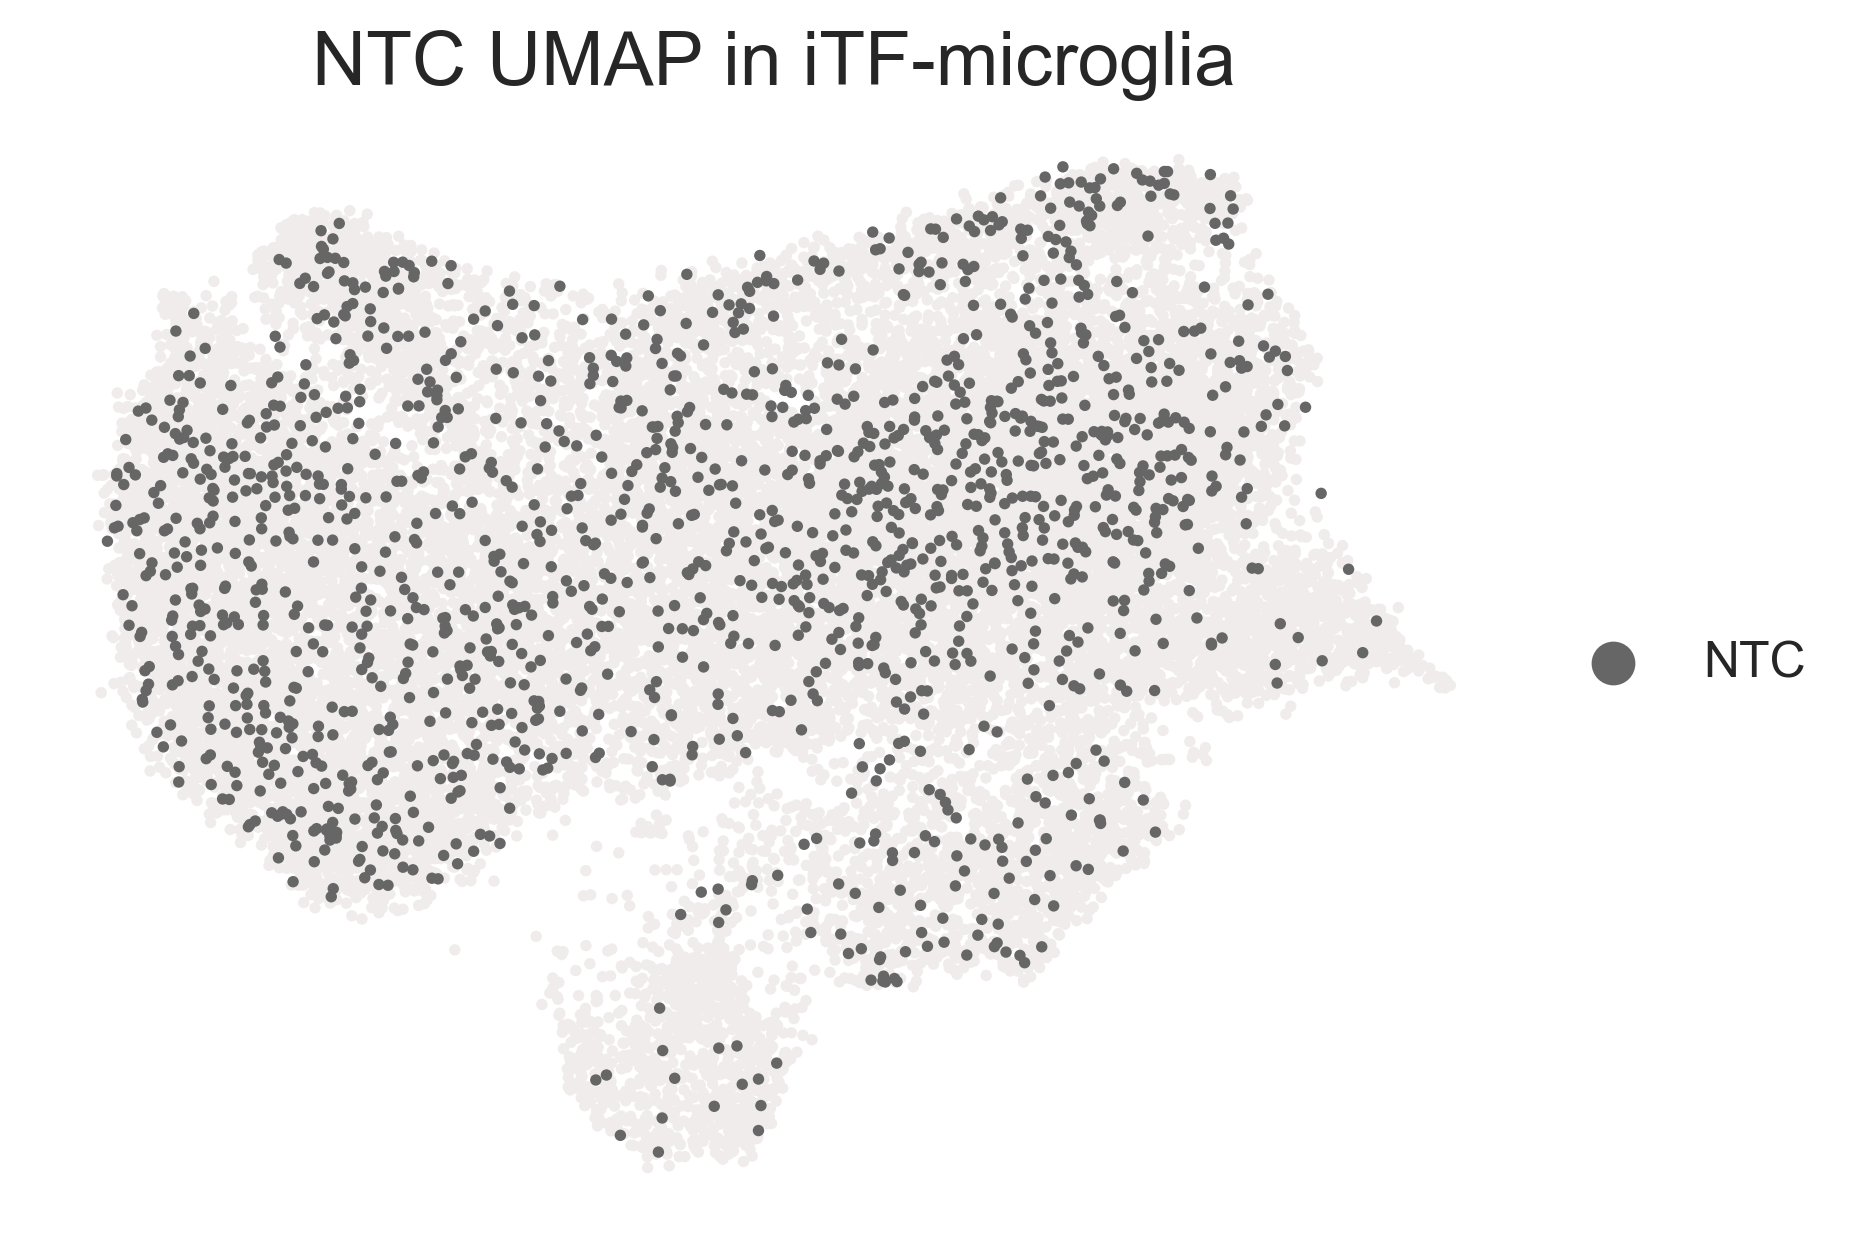

In [ ]:
sns.set_theme('talk', style='whitegrid', palette='viridis')



fig, ax = plt.subplots(dpi=300)
save_path = os.path.join(fig_dir_iTF, f"umap_with_NTC_colored")
sc.pl.umap(
        adata_dict['merged_6tf'],
        color='perturbed_guide',
        groups= ["NTC"],
        ncols=1,
        size=30,
        palette = factor_labels.palette_dict_6tf, 
        #palette = {"NTC":"#666666"}, 
        na_color="#f0eceb",
        na_in_legend=False,
        frameon=False,
        legend_fontsize = 12,
        title = f"NTC UMAP in iTF-microglia",
        ax = ax,
        show=False
)
plt.savefig(save_path + ".svg", bbox_inches='tight', dpi=300)
plt.savefig(save_path + ".png", bbox_inches='tight', dpi=300)
    
    

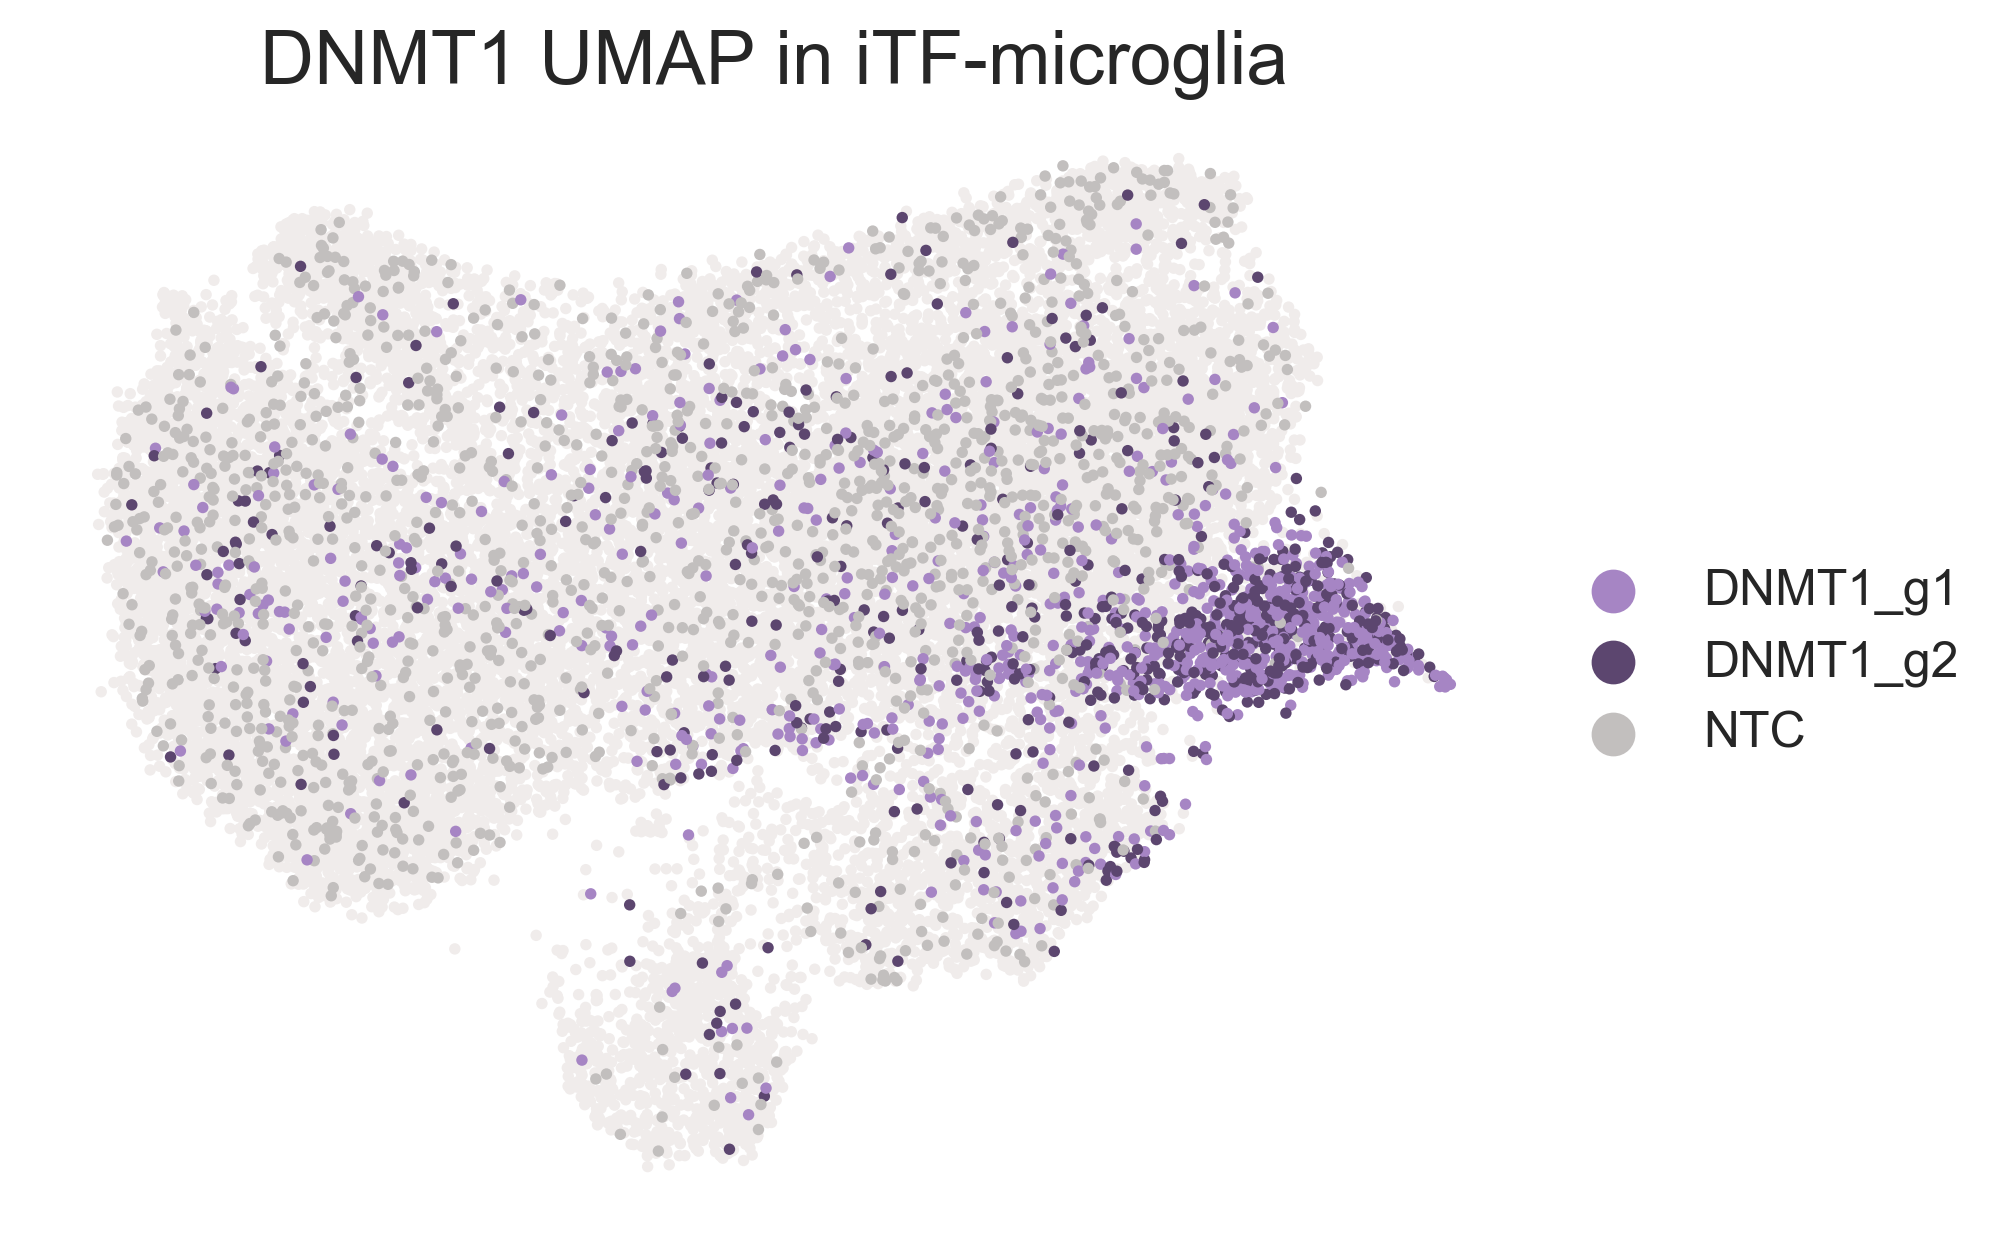

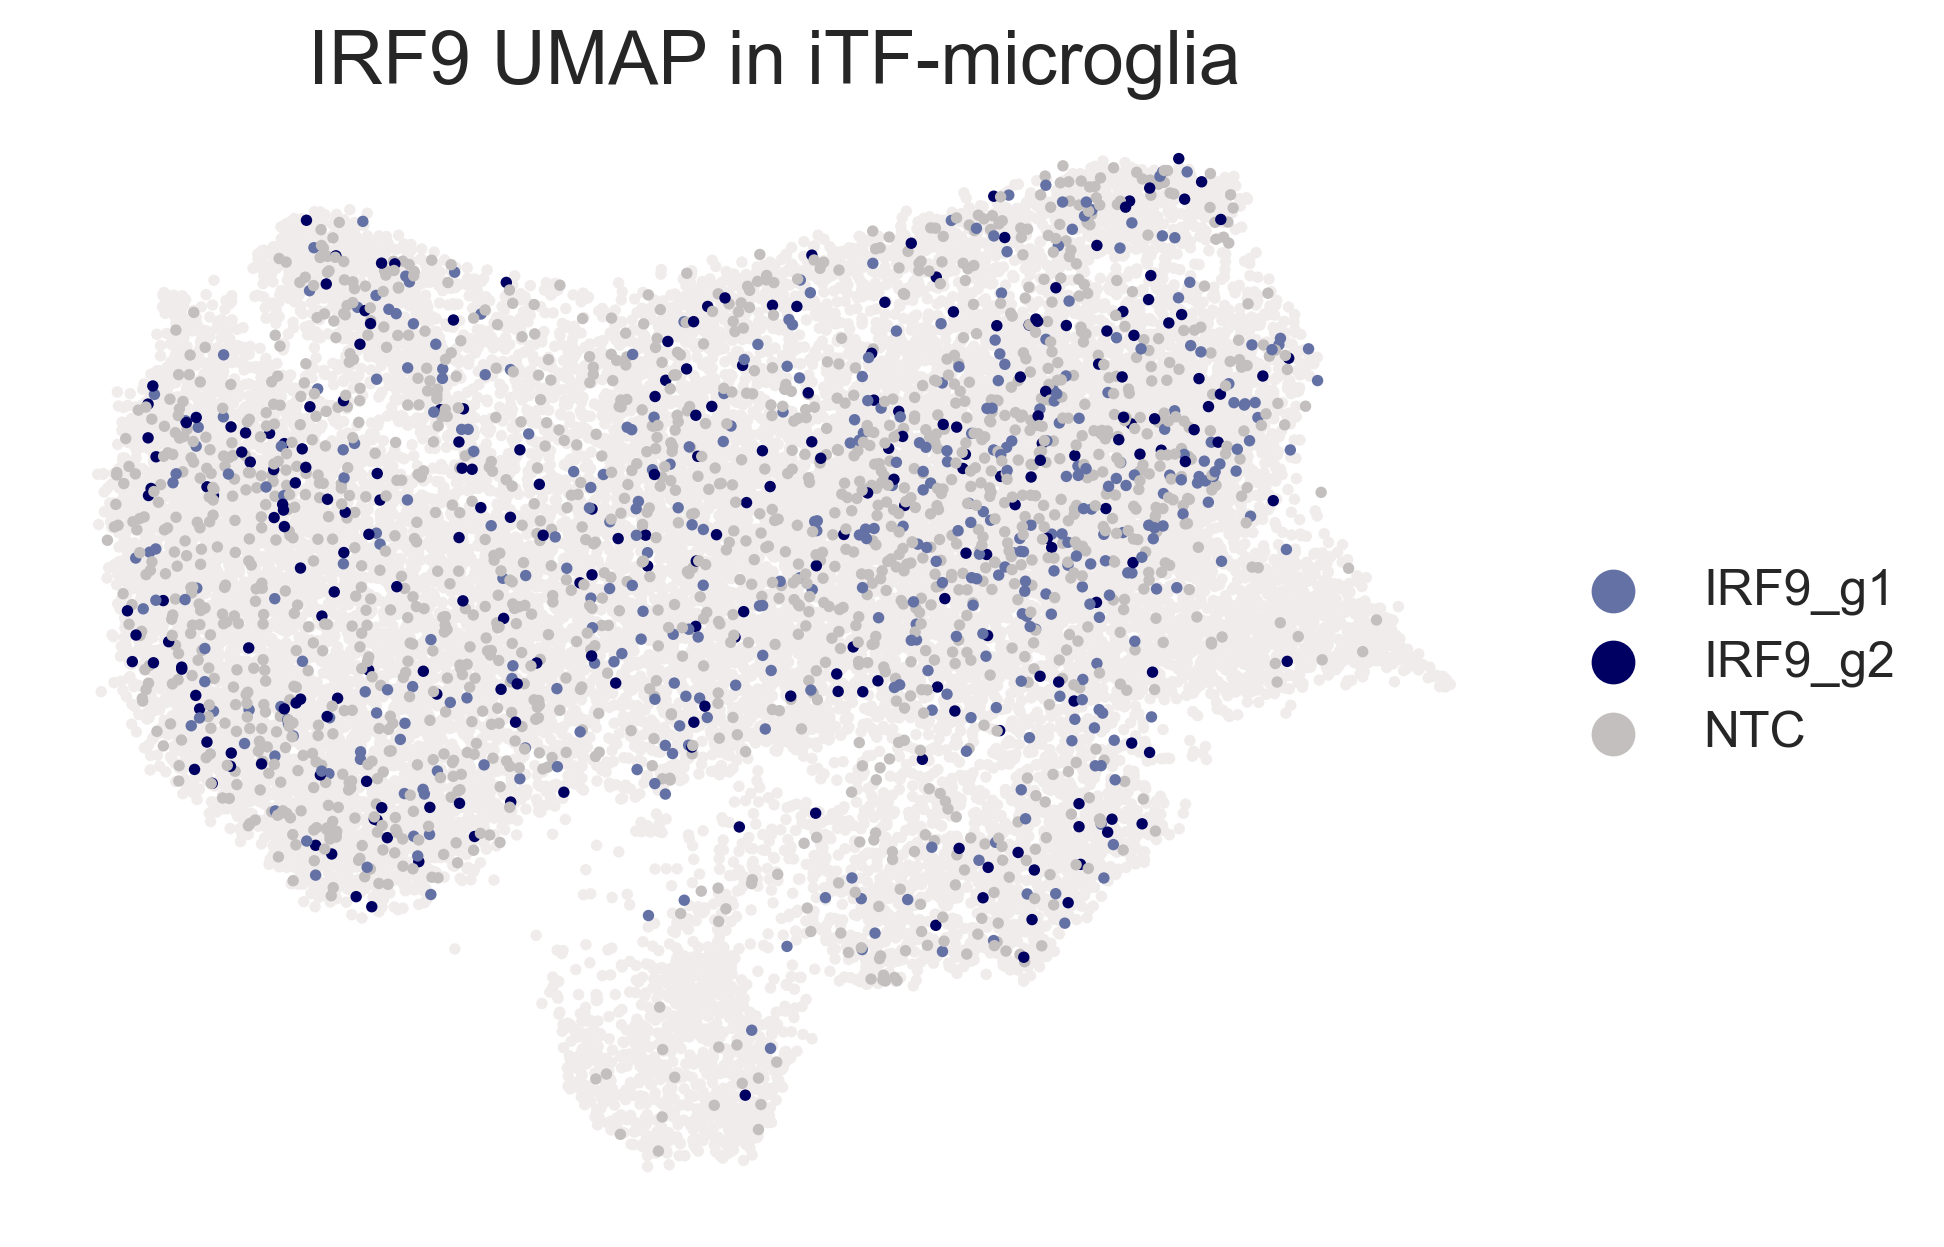

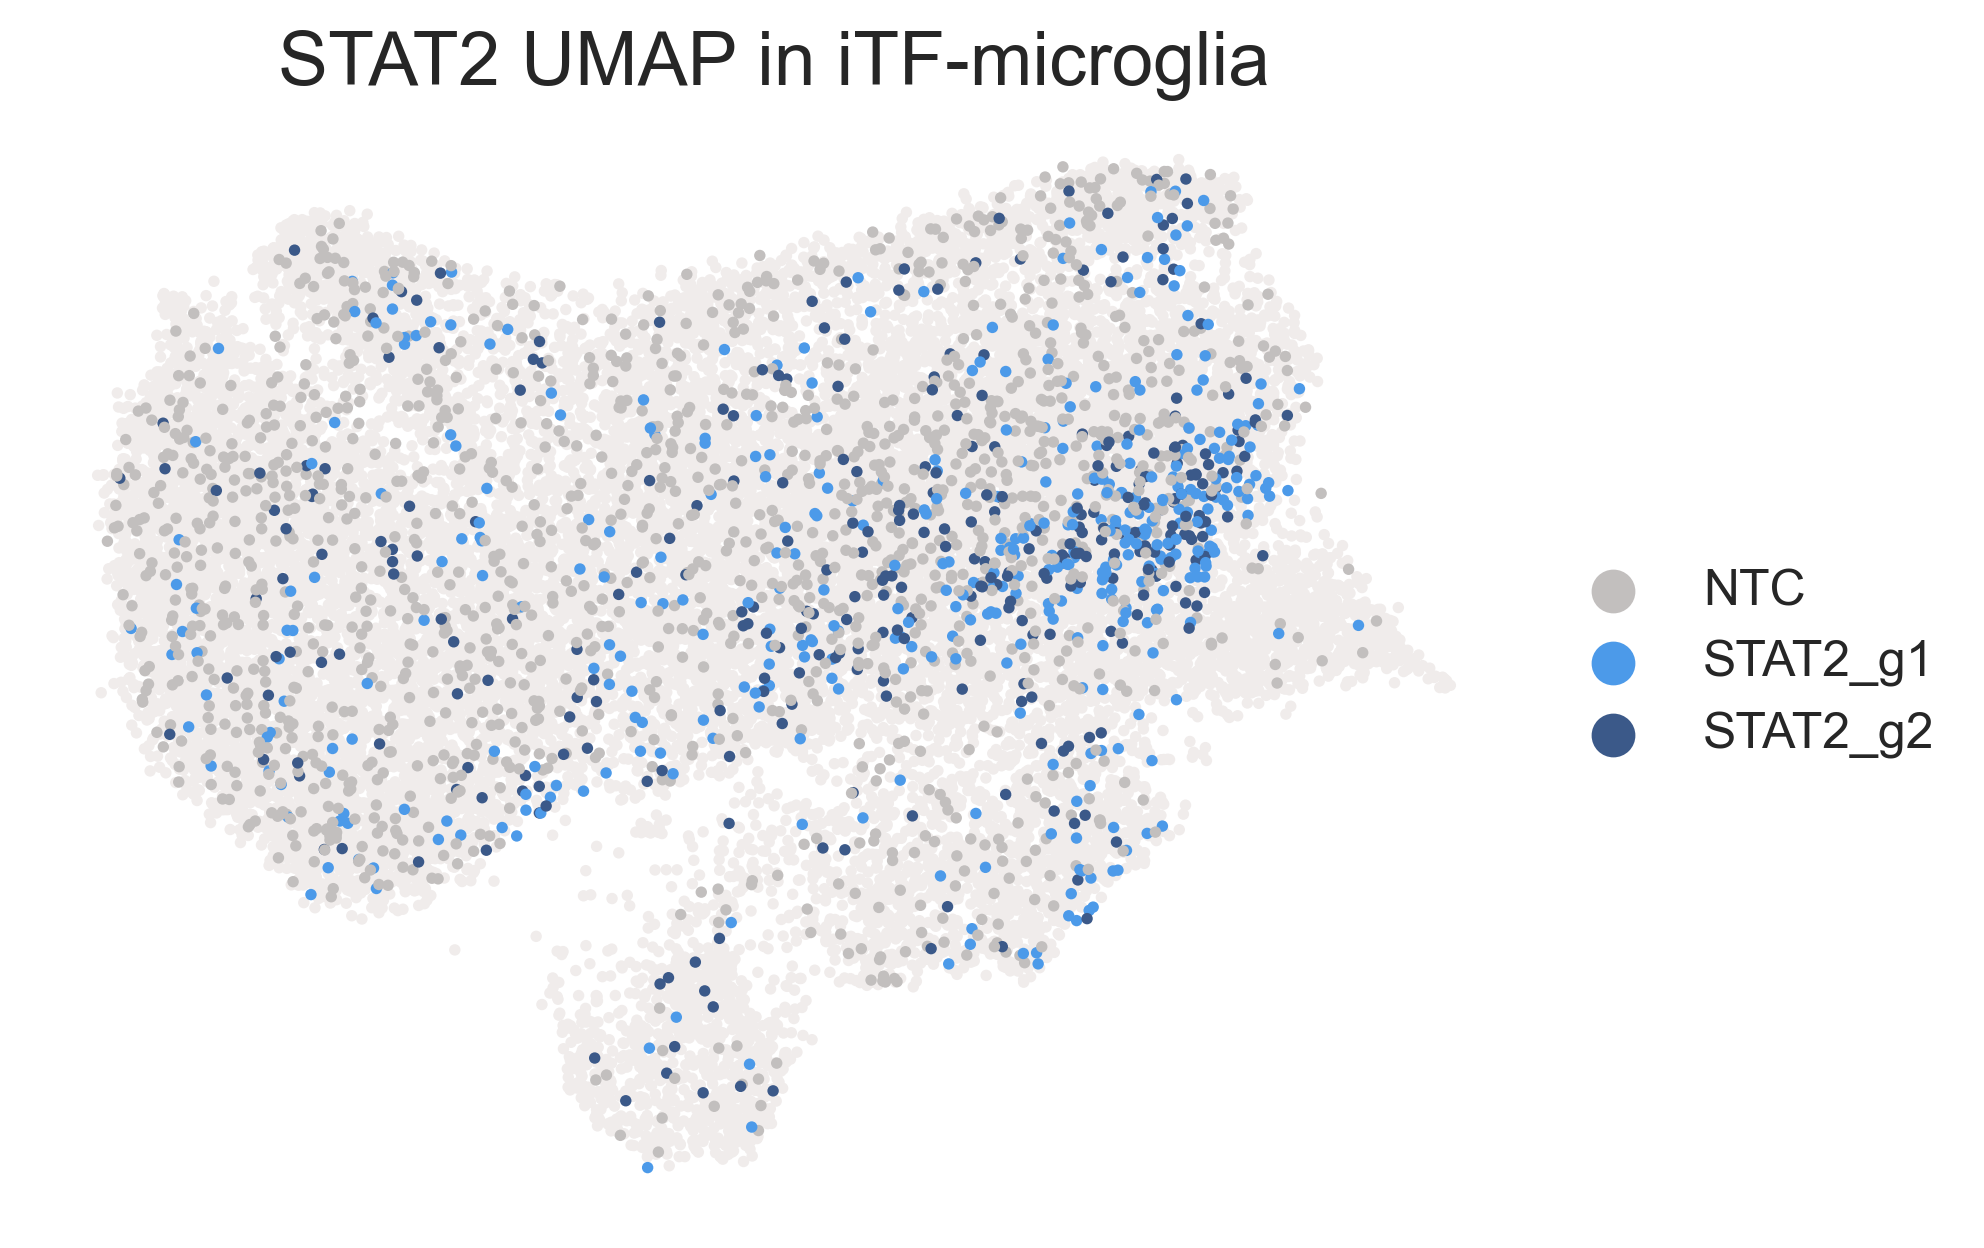

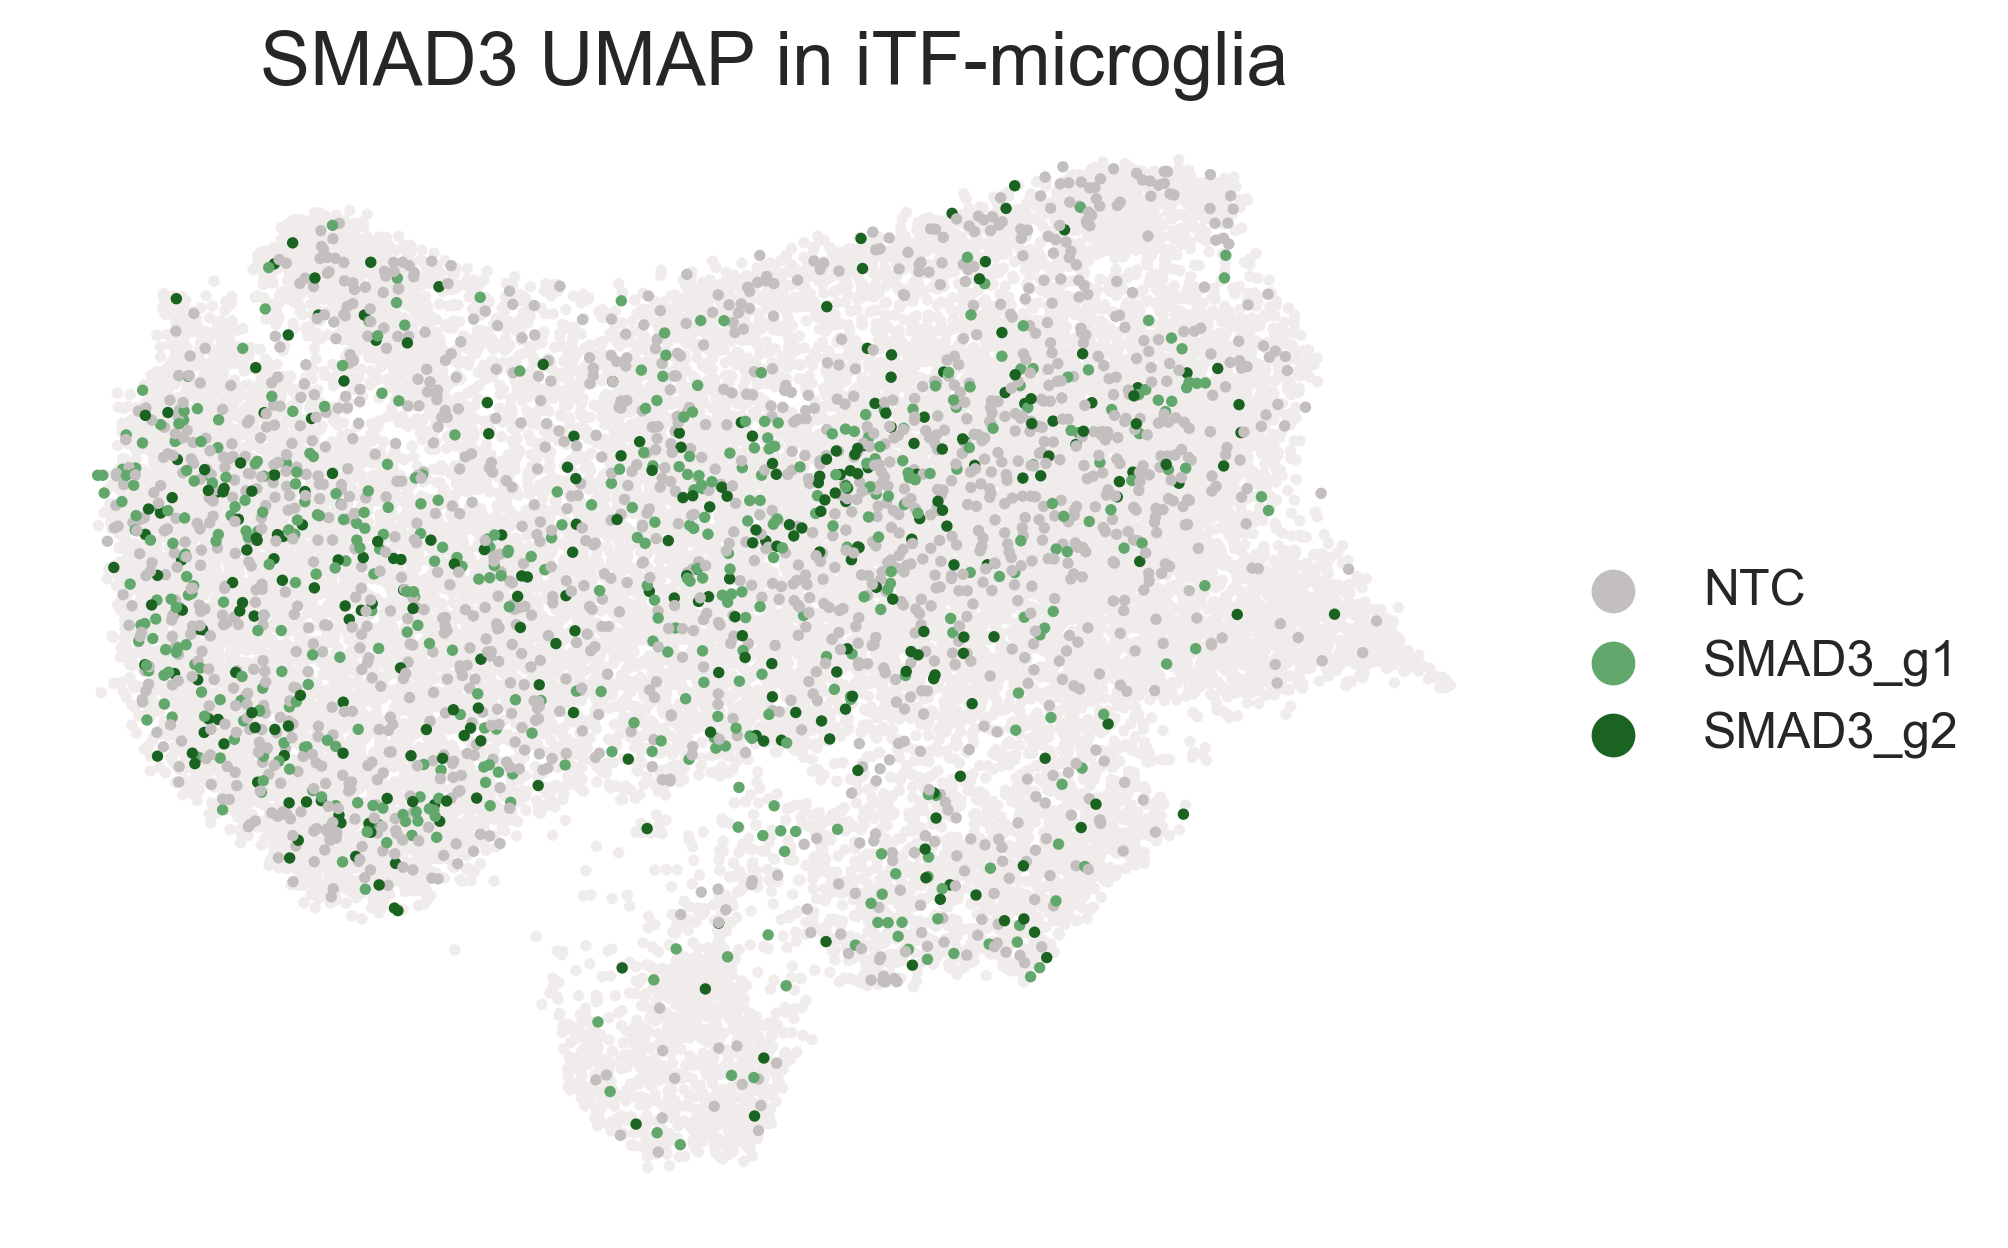

In [ ]:
sns.set_theme('talk', style='whitegrid', palette='viridis')


for gene in itf_genes:
    fig, ax = plt.subplots(dpi=300)
    save_path = os.path.join(fig_dir_iTF, f"umap_with_{gene}_colored")
    sc.pl.umap(
        adata_dict['merged_6tf'],
        color='perturbed_guide',
        groups= [gene + "_g1", gene + "_g2", "NTC"],
        ncols=1,
        size=30,
        palette = factor_labels.palette_dict_6tf, 
        na_color="#f0eceb",
        na_in_legend=False,
        frameon=False,
        legend_fontsize = 12,
        title = f"{gene} UMAP in iTF-microglia",
        ax = ax,
        show=False
    )
    

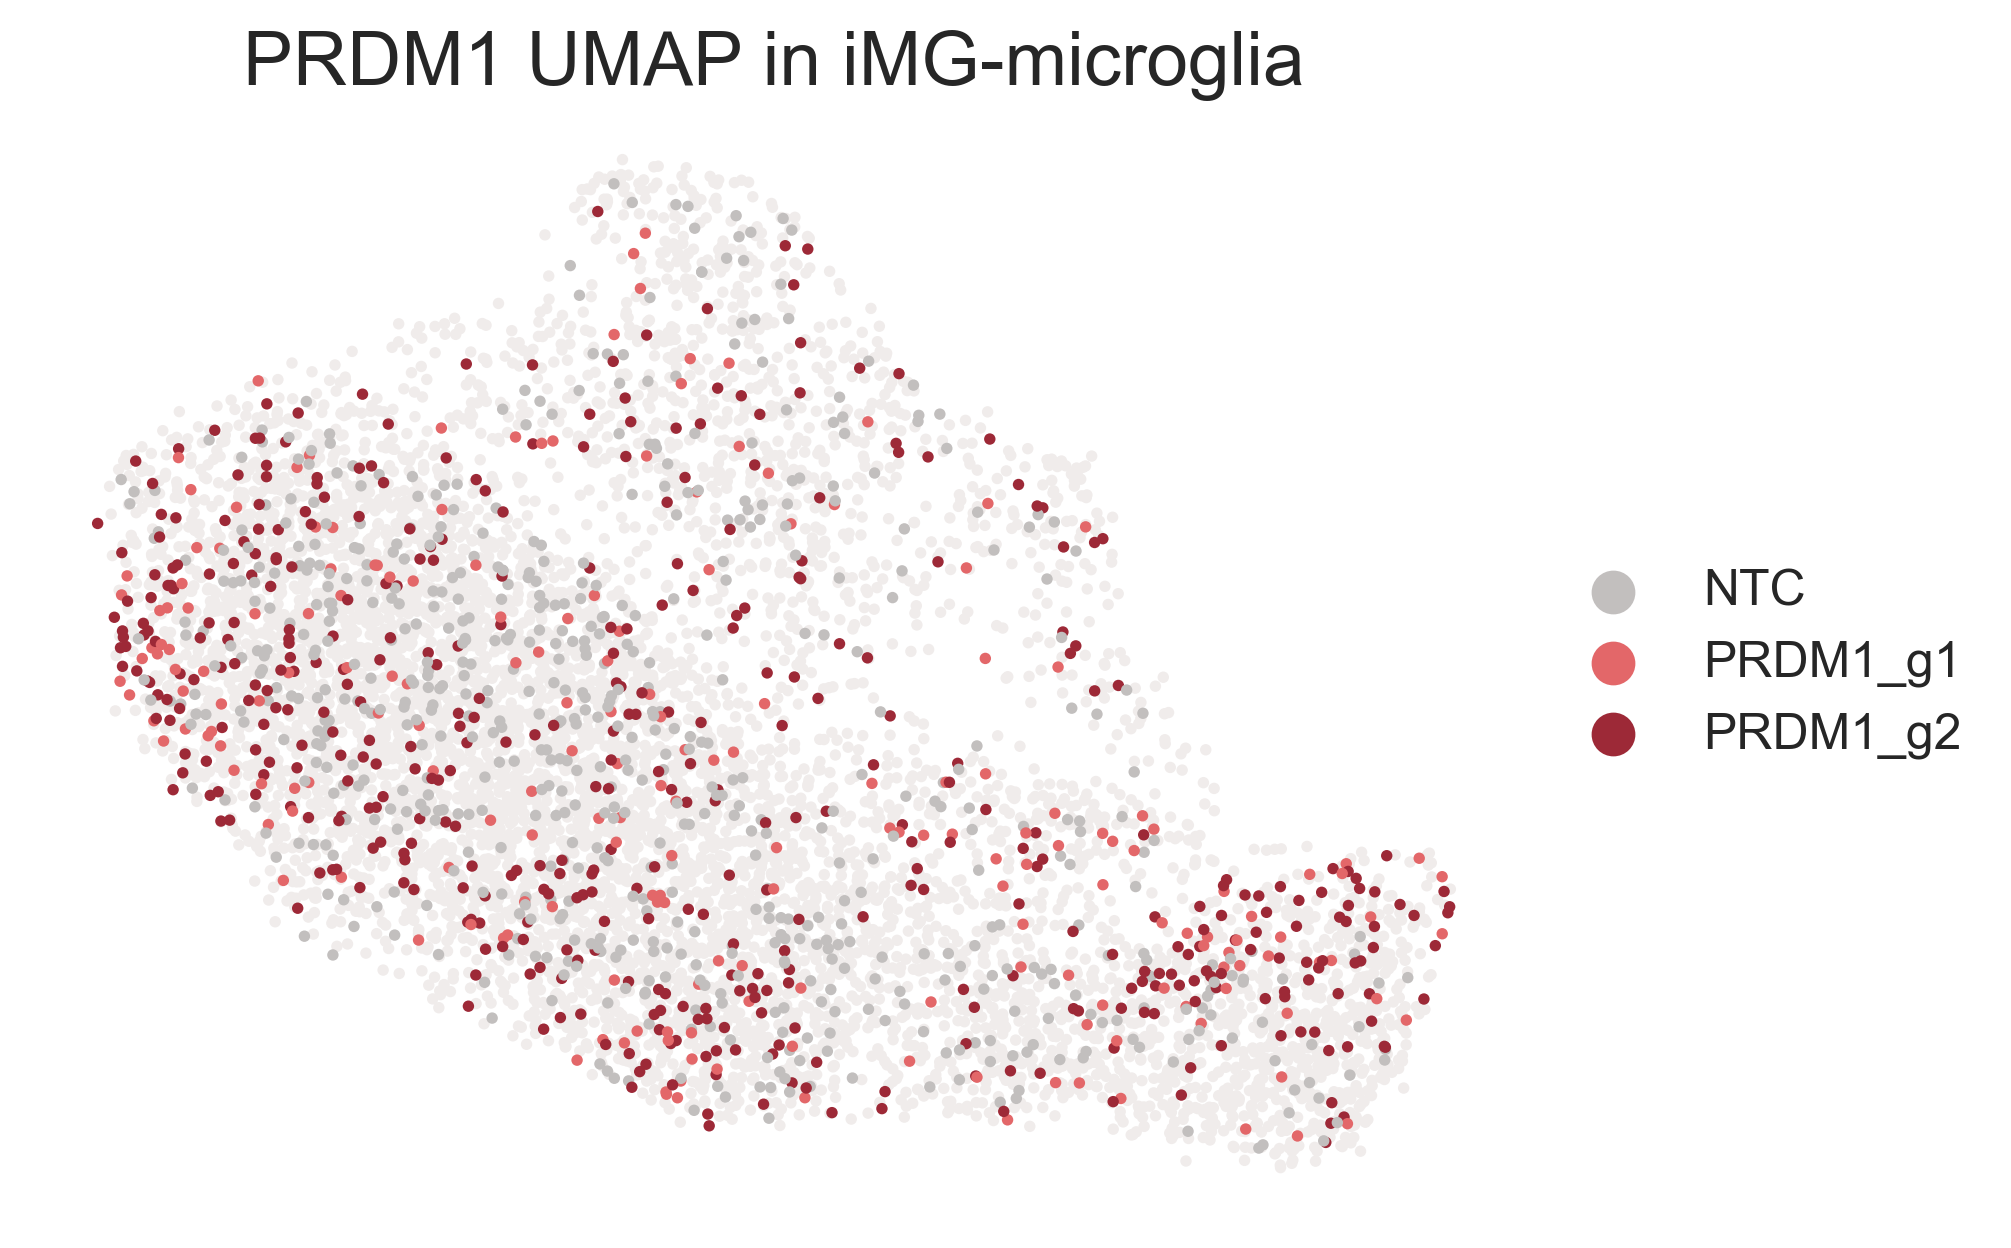

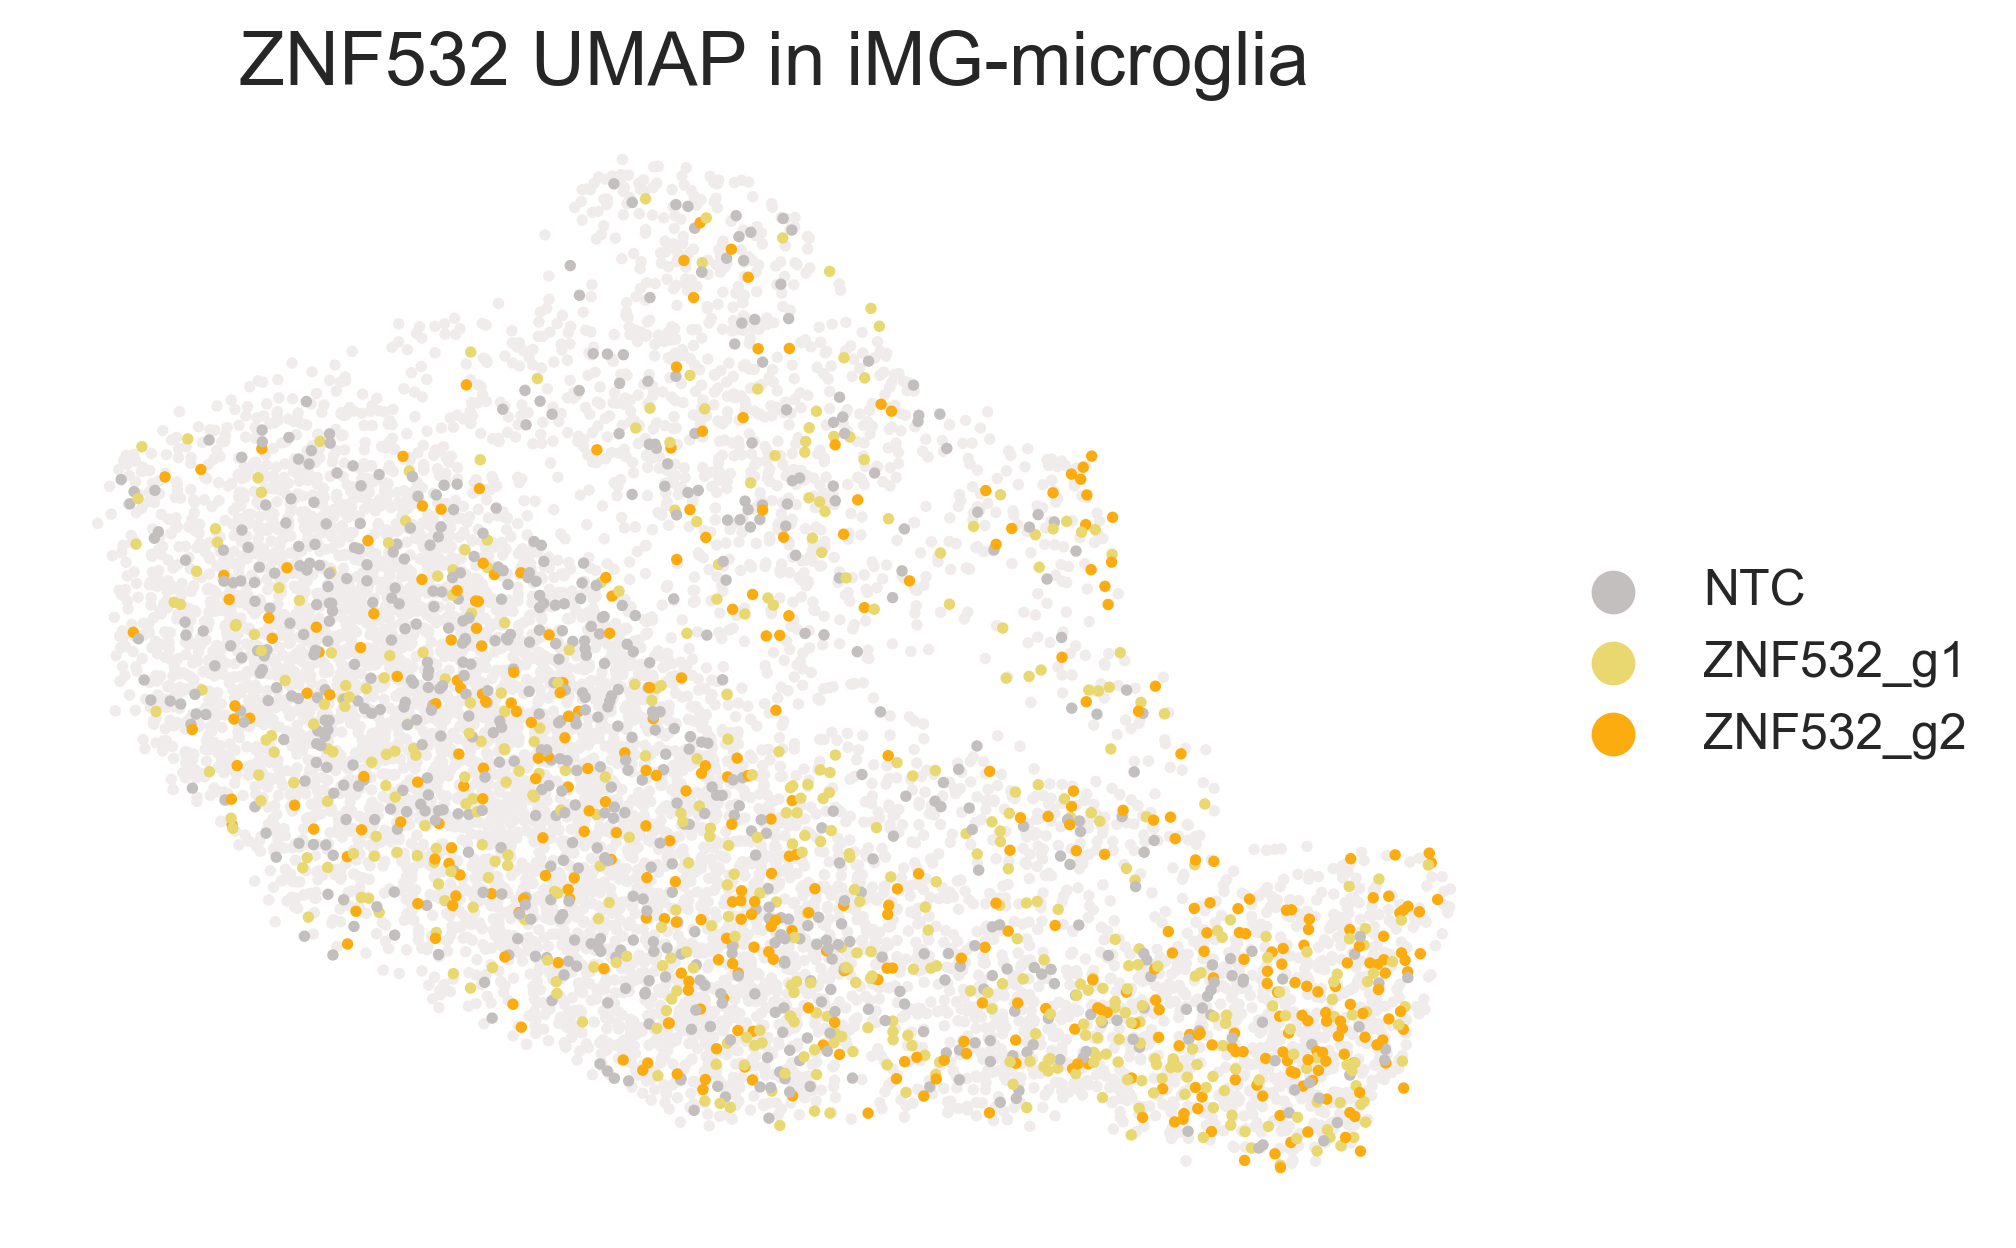

In [ ]:
sns.set_theme('talk', style='whitegrid', palette='viridis')


for gene in img_genes:
    fig, ax = plt.subplots(dpi=300)
    save_path = os.path.join(fig_dir_iMG, f"umap_with_{gene}_colored")
    sc.pl.umap(
        adata_dict['cite_imgl'],
        color='perturbed_guide',
        groups= [gene + "_g1", gene + "_g2", "NTC"],
        ncols=1,
        size=30,
        palette = factor_labels.palette_dict_imgl, 
        na_color="#f0eceb",
        na_in_legend=False,
        frameon=False,
        legend_fontsize = 12,
        title = f"{gene} UMAP in iMG-microglia",
        ax = ax,
        show=False
    )
    
    

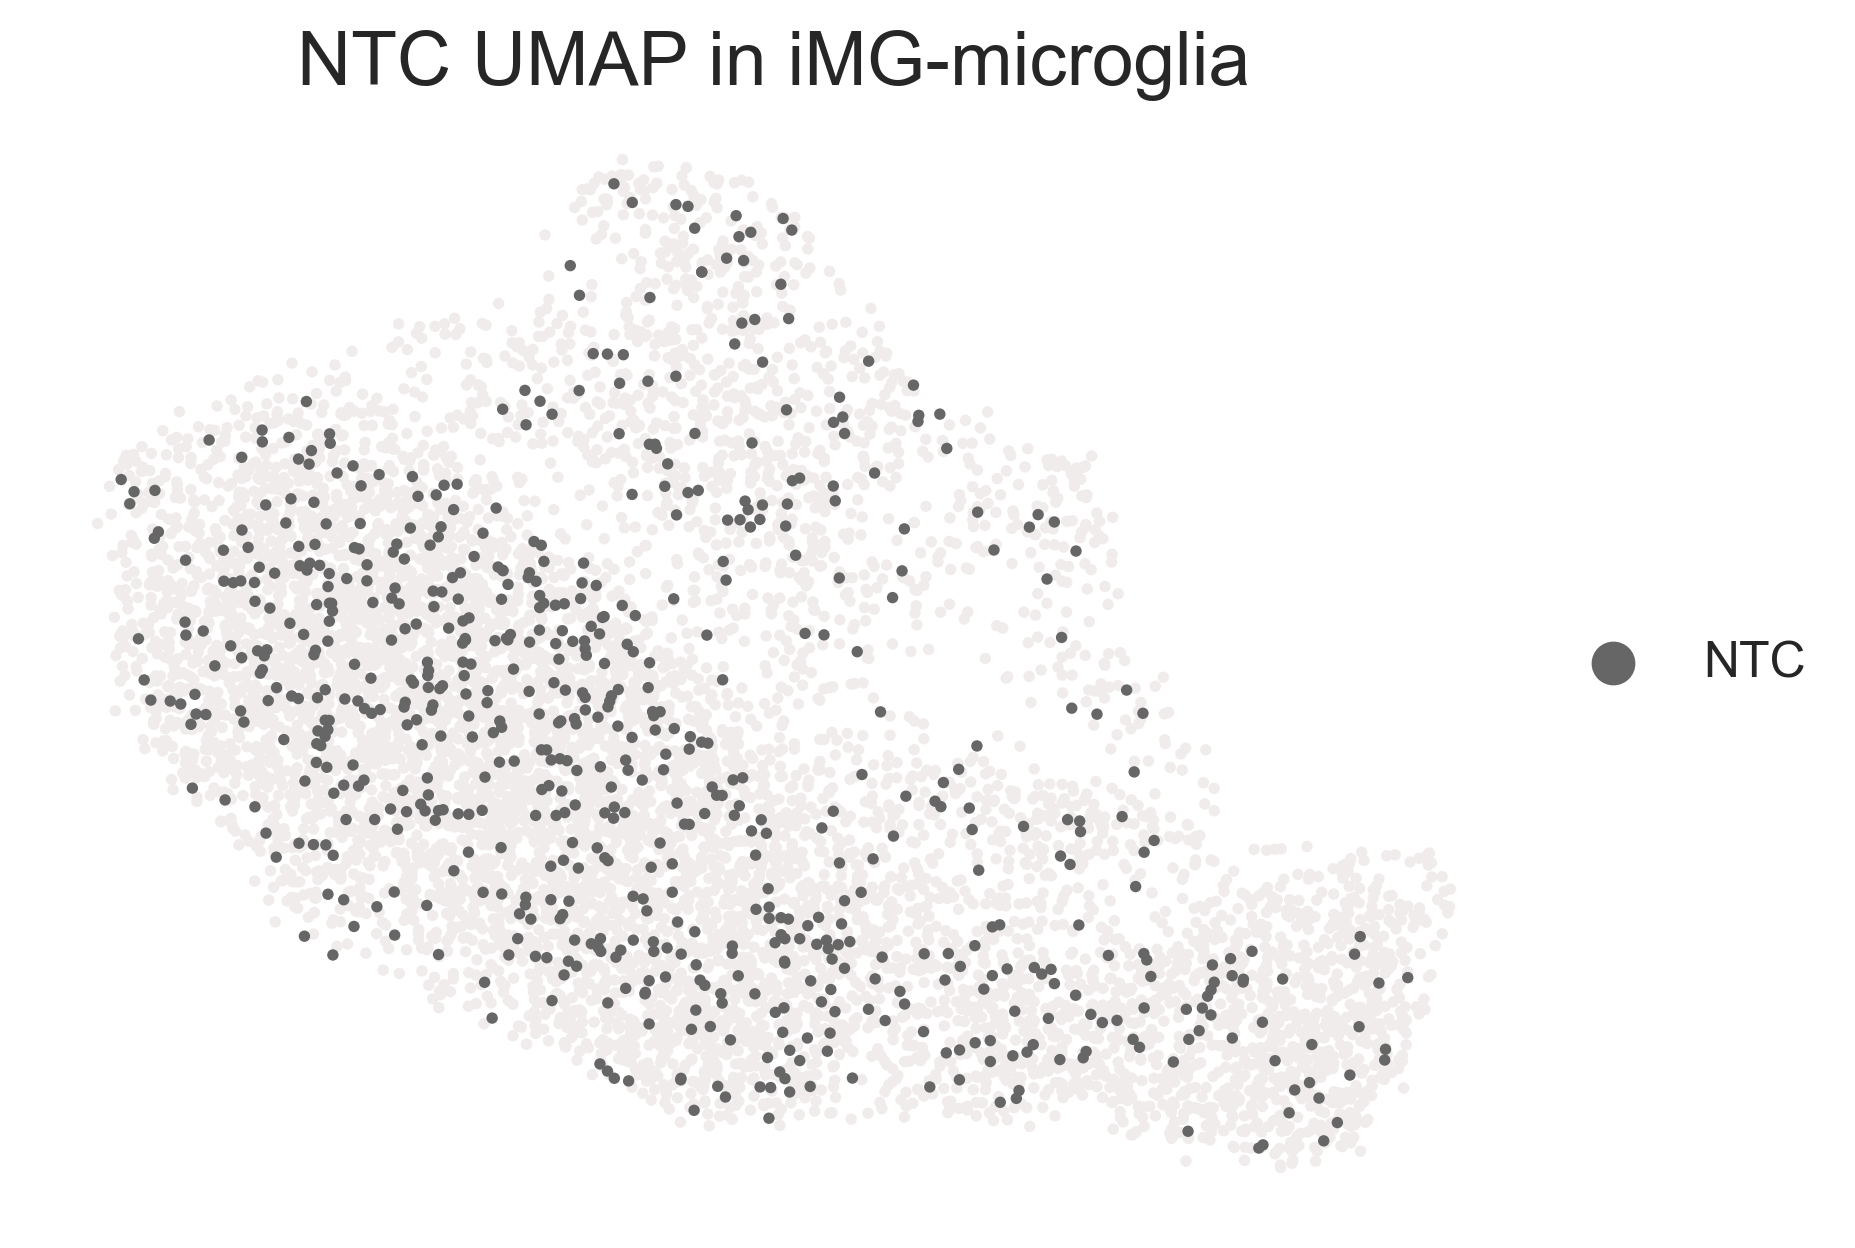

In [ ]:
sns.set_theme('talk', style='whitegrid', palette='viridis')



fig, ax = plt.subplots(dpi=300)
save_path = os.path.join(fig_dir_iMG, f"umap_with_NTC_colored")
sc.pl.umap(
        adata_dict['cite_imgl'],
        color='perturbed_guide',
        groups= ["NTC"],
        ncols=1,
        size=30,
        palette = factor_labels.palette_dict_imgl, 
        #palette = {"NTC":"#666666"}, 
        na_color="#f0eceb",
        na_in_legend=False,
        frameon=False,
        legend_fontsize = 12,
        title = f"NTC UMAP in iMG-microglia",
        ax = ax,
        show=False
)
plt.savefig(save_path + ".svg", bbox_inches='tight', dpi=300)
plt.savefig(save_path + ".png", bbox_inches='tight', dpi=300)

# Figure S5: iMG vs iTF median differences per signature


In [ ]:
all_median_differences_img_sorted = all_median_differences_img.sort_index()

In [ ]:
all_median_differences_itf_sorted = all_median_differences_itf.sort_index()

In [ ]:
# Correlate median differences between iMG and iTF models
common_genes = all_median_ps_img.index.intersection(all_median_ps_itf.index)
print(f"Common genes: {len(common_genes)} / iMG: {len(all_median_ps_img)} / iTF: {len(all_median_ps_itf)}")

img_common = all_median_ps_img.loc[common_genes]
itf_common = all_median_ps_itf.loc[common_genes]

img_common = img_common.drop("POU5F1")
itf_common = itf_common.drop("POU5F1")
common_genes = common_genes.drop("POU5F1")

# Per-signature Pearson correlation
corr_per_sig = {}
pval_per_sig = {}
for col in signature_cols_ordered:
    r, p = pearsonr(img_common[col], itf_common[col])
    corr_per_sig[col] = r
    pval_per_sig[col] = p

corr_per_sig_df = pd.DataFrame({'pearson_r': corr_per_sig, 'pval': pval_per_sig})
corr_per_sig_df['sig_label'] = corr_per_sig_df['pval'].apply(lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))
print(corr_per_sig_df.round(3))

In [ ]:
corr_per_sig_df

In [ ]:
short_names = {
    'homeostatic_score_ucell': 'Homeostatic',
    'interferon_score_ucell': 'Interferon',
    'chemokine_score_ucell': 'Chemokine',
    'antigen_presenting_score_ucell': 'Antigen Presenting',
    'dam_score_ucell': 'DAM',
    'lipid_dam_score_ucell': 'Lipid DAM',
}

In [ ]:
signature_cols_ordered_colors = {
    "homeostatic_score_ucell": "#107B35",
    "interferon_score_ucell": "#5FADAF",
    "chemokine_score_ucell": "#A335C2",
    "antigen_presenting_score_ucell": "#FDAC10",
    "dam_score_ucell": "#BF0063",
    "lipid_dam_score_ucell": "#E76333",
}

In [ ]:
annotations_fdr_img_df = annotations_fdr_img.sort_index().drop("POU5F1")

In [ ]:
annotations_fdr_itf_df = annotations_fdr_itf.sort_index().drop("POU5F1")

In [ ]:
all_annot_ps_img

In [ ]:
all_annot_ps_img = all_annot_ps_img.sort_index().drop(["POU5F1"],axis=0)
all_annot_ps_img= all_annot_ps_img.astype(bool)

all_annot_ps_itf = all_annot_ps_itf.sort_index().drop(["POU5F1"],axis=0)
all_annot_ps_itf= all_annot_ps_itf.astype(bool)

print(all_annot_ps_img.shape, all_annot_ps_itf.shape)

In [ ]:
annotations_fdr_img_df= annotations_fdr_img_df.astype(bool)
annotations_fdr_itf_df= annotations_fdr_itf_df.astype(bool)

In [ ]:
annot_matrix = all_annot_ps_img.astype(int) + all_annot_ps_itf.astype(int) * 2
# 0 = none sig
# 1 = sig only in img
# 2 = sig only in itf
# 3 = sig in both

In [ ]:
model_state_combo_colors = {
    0: '#6D6D6D',   # none sig  
    1: '#773410',   # iMG only   
    2: '#0B5202',   # iTF only   
    3: '#000000',   # both sig
}

In [ ]:
ncols = 3
nrows = int(np.ceil(len(signature_cols_ordered) / ncols))
sns.set_theme("talk", style="white")
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5), constrained_layout=True, dpi=300)

for idx, col in enumerate(signature_cols_ordered):
    ax = axes.flat[idx]
    x = itf_common[col]
    y = img_common[col]
    r = corr_per_sig_df.loc[col, 'pearson_r']
    sig = corr_per_sig_df.loc[col, 'sig_label']

    gene_states = annot_matrix.loc[common_genes, col]  

    for state, color in model_state_combo_colors.items():
        mask = gene_states == state
        if mask.any():
            ax.scatter(x[mask], y[mask], color=color, edgecolors='none',
                       s=80, zorder=3)
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m * xline + b, color='black', lw=1.5, ls='--')


    ax.set_xlabel('iTF median diff', fontsize=14)
    ax.set_ylabel('iMG median diff', fontsize=14)
    ax.set_title(f"{short_names[col]}\nr = {r:.2f} {sig}", fontsize=14)
    ax.axhline(0, color="#AAAAAA", lw=0.9, ls=':', zorder=1)
    ax.axvline(0, color="#AAAAAA", lw=0.9, ls=':', zorder=1)

    ylim = abs(y).max() * 1.15
    ax.set_ylim(-ylim, ylim)

    xlim = abs(x).max() * 1.15
    ax.set_xlim(-xlim, xlim)

for i in range(len(signature_cols_ordered), nrows * ncols):
    fig.delaxes(axes.flat[i])

plt.suptitle("iMG vs iTF: Median Difference Correlation per Signature", fontsize=14, y=1.02)
plt.savefig("figures/in_vitro/img_vs_itf_median_diff_correlation_fixed_wotext_ps.svg", bbox_inches="tight", dpi=300)
plt.show()

## Protein Correlation Volcanos

In [ ]:
mdata_masked_dict = {}
mdata_masked_dict['cite_6tf'] = mdata_6tf_clean
mdata_masked_dict['cite_imgl'] = mdata_imgl_clean

In [ ]:
def get_corr_pval(df1, df2):
    corr = pd.DataFrame(index=df1.columns, columns=df2.columns, dtype=float)
    pval = pd.DataFrame(index=df1.columns, columns=df2.columns, dtype=float)
    adj_pval = pd.DataFrame(index=df1.columns, columns=df2.columns, dtype=float)

    for c1 in df1.columns:
        for c2 in df2.columns:
            r, p = pearsonr(df1[c1], df2[c2])
            corr.loc[c1, c2] = r
            pval.loc[c1, c2] = p

    pvals_flat = pval.values.flatten()
    _, adj_pvals_flat, _, _ = multipletests(pvals_flat, method='fdr_bh')
    adj_pval.iloc[:, :] = adj_pvals_flat.reshape(pval.shape)
    return corr, adj_pval

def significance_stars(pvals):
    stars = np.full(pvals.shape, "", dtype=object)
    stars[pvals < 0.05] = "*"
    stars[pvals < 0.01] = "**"
    stars[pvals < 0.001] = "***"
    return stars



In [ ]:
def plot_corr_heatmap(corr_df, pval_df, figname, vmin = -1, vmax = 1, cmap = "vlag", 
                      alphabetical = True, figsize = (6, 40), zoom = False, flip=False,
                      row_cluster=True, col_cluster=True):
    
    if zoom:
        vmin = -0.2
        vmax = 0.2
    
    annot_df = significance_stars(pval_df)
    
    if flip:
        corr_df = corr_df.T
        annot_df = annot_df.T
        figsize = (figsize[1], figsize[0])
    
    if alphabetical:
        plt.figure(figsize = figsize, dpi=300)
        sns.heatmap(corr_df, cmap= cmap, center=0, annot=annot_df, fmt="", 
                    cbar_kws={"label": "Correlation"}, vmin = vmin, vmax= vmax)
        plt.title(f"Protein vs RNA Signature Score Correlation: {name}")
        plt.xlabel("RNA Program Scores")
        plt.ylabel("Proteins")
        plt.tight_layout()
        plt.savefig(figname, dpi=300)

        plt.show()
    else:
        g = sns.clustermap(corr_df, cmap= cmap, center=0, annot=annot_df, fmt="", 
                    cbar_kws={"label": "Correlation"}, vmin = vmin, vmax= vmax, figsize = (figsize[0], figsize[1] + 20),
                    row_cluster=row_cluster, col_cluster=col_cluster)
        plt.title(f"Protein vs RNA Signature Score Correlation: {name}")
        plt.xlabel("RNA Program Scores")
        plt.ylabel("Proteins")
        plt.tight_layout()
        g.savefig(figname, dpi=300)

        plt.show()

In [ ]:
color_dict  = {
    "dam_score_ucell": "#BF0063",
    "homeostatic_score_ucell": "#107B35",
    "interferon_score_ucell": "#5FADAF",
    "chemokine_score_ucell": "#A335C2",
    "lipid_dam_score_ucell": "#E76333",
    "antigen_presenting_score_ucell": "#FDAC10",
}
  

In [ ]:
def plot_corr_volanos(corr_df, pval_df, type, figname, ncols=5, add_text = True):
    nrows = int(np.ceil(len(corr_df.columns) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4), constrained_layout=True)
    for idx, col in enumerate(corr_df.columns):
        x = corr_df[col]
        pvals = pval_df[col]
        _, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')
        y = pd.Series(-np.log10(pvals_adj), index=x.index)
        y_clipped = y.clip(upper=500)  

        top10_idx = np.argsort(pvals_adj)[:20]
        ax = axes.flat[idx]
        ax.scatter(x, y_clipped, color=color_dict[col])
        texts = []
        
        for j, tidx in enumerate(top10_idx):
            true_y = y.iloc[tidx]
            y_val = y_clipped[tidx]
            if true_y > 500:
                y_val = 500 + j * 2
            if add_text:
                texts.append(
                ax.text( 
                    x.iloc[tidx],
                    y_val,
                    x.index[tidx],
                    fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.2', fc='lightblue', alpha=0.5, lw=0.5),
                ))
        if add_text:
            adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="->"), )

        ax.set_xlabel('Pearson correlation')
        ax.set_ylabel('-log10(FDR)')
        ax.set_title(f'{col}')
        ax.grid(True, alpha=0.3)

    for i in range(len(corr_df.columns), nrows*ncols):
        fig.delaxes(axes.flat[i])

    plt.suptitle(f'Correlation vs Significance for Each {type}', fontsize=16, y=1.02)
    plt.savefig(figname, dpi=300)
    plt.show()


In [ ]:
corr_df_dict = {}
pval_df_dict = {}

for name, mdata in mdata_masked_dict.items():
    print(name, mdata.shape)
    if "tf" in name:
        fig_dir = "<path to resulting figure directory>"
    else:
        fig_dir = "<path to resulting figure directory>"
    prot_expr =  mdata['prot'].X.toarray()
    prot_names = mdata['prot'].var_names
    rna_scores = mdata['rna'].obs.filter(regex='_score_ucell')
    rna_scores = rna_scores[rna_scores.columns[rna_scores.columns.isin(signature_cols_ordered)]]
    rna_score_names = rna_scores.columns
    rna_mat = rna_scores.values
    
    corr_matrix = np.zeros((prot_expr.shape[1], rna_mat.shape[1]))
    pval_matrix = np.ones((prot_expr.shape[1], rna_mat.shape[1]))

    for i in range(prot_expr.shape[1]):       
        for j in range(rna_mat.shape[1]):     
            r, p = pearsonr(prot_expr[:, i], rna_mat[:, j])
            corr_matrix[i, j] = r
            pval_matrix[i, j] = p
            
    corr_df = pd.DataFrame(corr_matrix, index=prot_names, columns=rna_score_names).sort_index()
    pval_df = pd.DataFrame(pval_matrix, index=prot_names, columns=rna_score_names).sort_index()
    
    adj_pval_df = pval_df.copy()
    for col in pval_df.columns:
        _, adj_pvals_col, _, _ = multipletests(pval_df[col].values, method='fdr_bh')
        adj_pval_df[col] = adj_pvals_col

    pval_df_dict[name] = adj_pval_df
    corr_df_dict[name] = corr_df
    
    mdata.uns['corr_df_signature'] = corr_df
    mdata.uns['pval_df_signature'] = adj_pval_df
    
    sns.set_theme("poster", "white")
    plot_corr_volanos(corr_df, adj_pval_df, "Signature", ncols=1, 
                      figname = f"{fig_dir}/{name}_protein_volcano.jpeg", 
                      add_text=False)

# Protein Count Barplots

In [ ]:
deg_dir = "<path to calculated mixscale DEGs>"

deg_dict = {}
sig_deg_dict = {}
pval_threshold = 0.05
logfc_threshold = 0
#genes = ['STAT2', 'DNMT1', 'SMAD3', 'IRF9', 'PRDM1', 'ZNF532']
genes = sorted(list(adata_6tf_clean.obs.perturbed_gene.unique()))
for model in ['merged_6tf', 'cite_imgl']:
    sig_deg_dict[model] = {}
    deg_dict[model] = {}
    for gene in genes:
        if gene == "NTC":
            continue
        if model == "merged_6tf":
            path = deg_dir + f"/{model}_mixscale_degs_all_prot_{gene}.csv"
        else:
            path = deg_dir + f"/{model}_mixscale_degs_all_prot_{gene}.csv"
        if os.path.exists(path):
            deg_dict[model][gene] = pd.read_csv(path, index_col = 0)
            deg_dict[model][gene]['gene_ID'] = deg_dict[model][gene].index
            sig_deg_dict[model][gene] = {}
            sig_deg_dict[model][gene]['df'] = deg_dict[model][gene][deg_dict[model][gene]['adj_p_weight'] <= pval_threshold].copy()
            sig_deg_dict[model][gene]['negative'] = sig_deg_dict[model][gene]['df'][sig_deg_dict[model][gene]['df']['log2FC'] <= logfc_threshold].copy()
            sig_deg_dict[model][gene]['positive'] = sig_deg_dict[model][gene]['df'][sig_deg_dict[model][gene]['df']['log2FC'] > logfc_threshold].copy()

In [ ]:
num_daps_itf = []
num_daps_img = []
for gene in genes:
    if gene == "NTC":
        continue
    num_daps_itf.append(sig_deg_dict['merged_6tf'][gene]['df'].shape[0])
    num_daps_img.append(sig_deg_dict['cite_imgl'][gene]['df'].shape[0])

In [ ]:
genes.remove("NTC")

In [ ]:
num_prot_df = pd.DataFrame([genes,num_daps_itf, num_daps_img]).T
num_prot_df = num_prot_df.rename(columns={0:"perturbed_gene", 1:"num_DAPs_iTF", 2:"num_DAPs_iMG"})

In [ ]:
num_prot_df = num_prot_df.replace(np.nan, 0)

In [ ]:
sns.set_theme("poster", "white")
fig, ax = plt.subplots( dpi=300)
sns.barplot(num_prot_df[num_prot_df.num_DAPs_iTF != 0].sort_values(by="num_DAPs_iTF", ascending=False), 
            x='perturbed_gene', y='num_DAPs_iTF', ax=ax)
plt.savefig("figures/iTF/final/itf_num_dap.svg")

In [ ]:
fig, ax = plt.subplots( dpi=300)
sns.barplot(num_prot_df[num_prot_df.num_DAPs_iMG != 0].sort_values(by="num_DAPs_iMG", ascending=False), 
            x='perturbed_gene', y='num_DAPs_iMG', ax=ax)
plt.savefig("figures/iMG/final/img_num_dap.svg")

## ---------------------- Finished Figure 2 ------------------------